In [5]:
# import subprocess
# result = subprocess.run(["ls", "-lh", "/home/users/bidyut/UoE/20260112_Basic_Analysis/"], 
#                         capture_output=True, text=True)
# print(result.stdout)

In [6]:
# import os
# for f in sorted(os.listdir("/home/users/bidyut/UoE/20260112_Basic_Analysis/")):
#     print(f)

In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Open dataset
ds = xr.open_dataset('/home/users/bidyut/UoE/20260112_Basic_Analysis/MSE_daily_flux_components_NoBarotropCorr_20260304.nc')



In [8]:
print(ds)

<xarray.Dataset> Size: 4GB
Dimensions:                          (lat: 145, lon: 192, time: 720, plev: 8)
Coordinates:
  * lat                              (lat) float64 1kB -90.0 -88.75 ... 90.0
  * lon                              (lon) float64 2kB 0.0 1.875 ... 356.2 358.1
  * time                             (time) object 6kB 2001-01-01 12:00:00 .....
  * plev                             (plev) float64 64B 1e+05 8.5e+04 ... 1e+03
Data variables:
    Flambda_div                      (time, lat, lon) float32 80MB ...
    Fphi_div                         (time, lat, lon) float32 80MB ...
    h_on_v                           (time, plev, lat, lon) float32 641MB ...
    v_mean                           (time, plev, lat, lon) float32 641MB ...
    v_corr                           (time, plev, lat, lon) float64 1GB ...
    vh                               (time, plev, lat, lon) float32 641MB ...
    vh_int                           (time, lat, lon) float64 160MB ...
    uh_int             

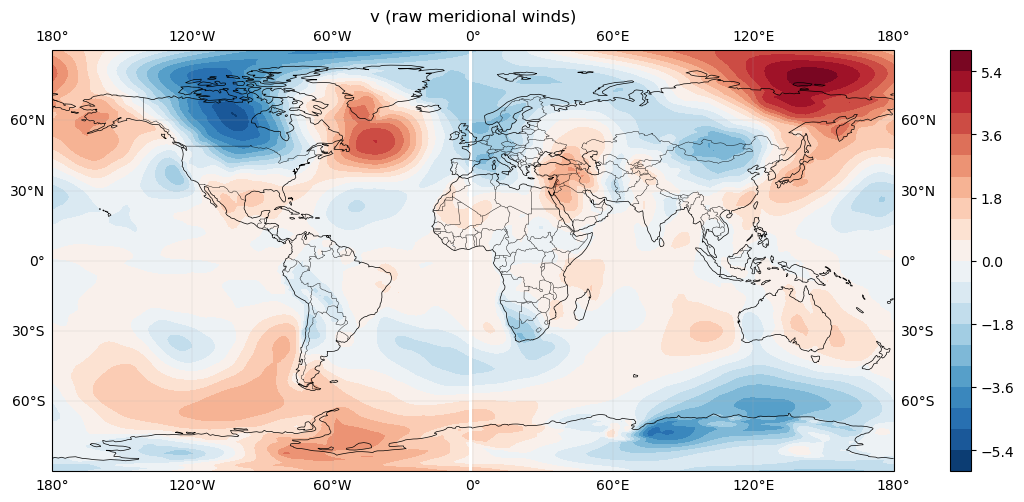

In [9]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
# v = ds['v_mean'].mean(dim="time") 
v = ds['v_mean'].mean(dim=["time","plev"])
# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(ds.lon, ds.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("v (raw meridional winds)")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



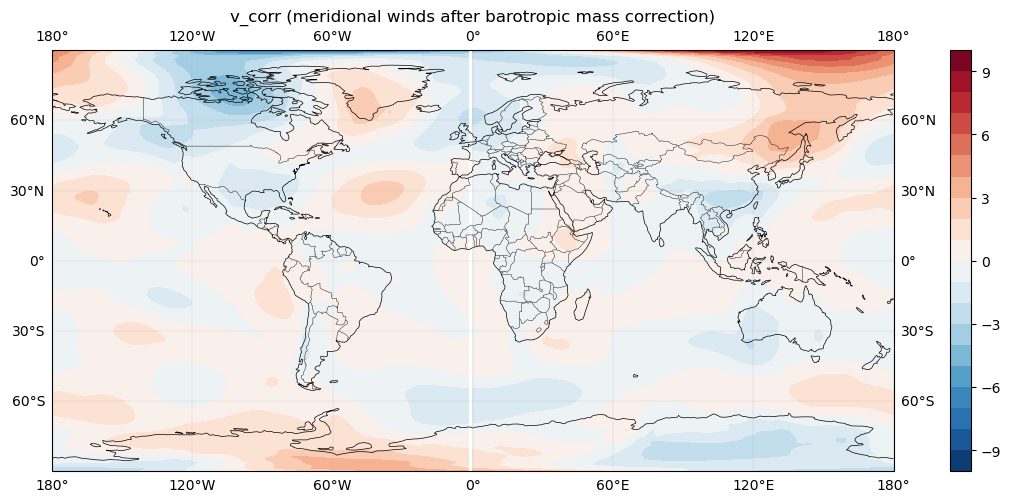

In [10]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
# v = ds['v_mean'].mean(dim="time") 
v = ds['v_corr'].mean(dim=["time","plev"])
# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(ds.lon, ds.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("v_corr (meridional winds after barotropic mass correction)")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



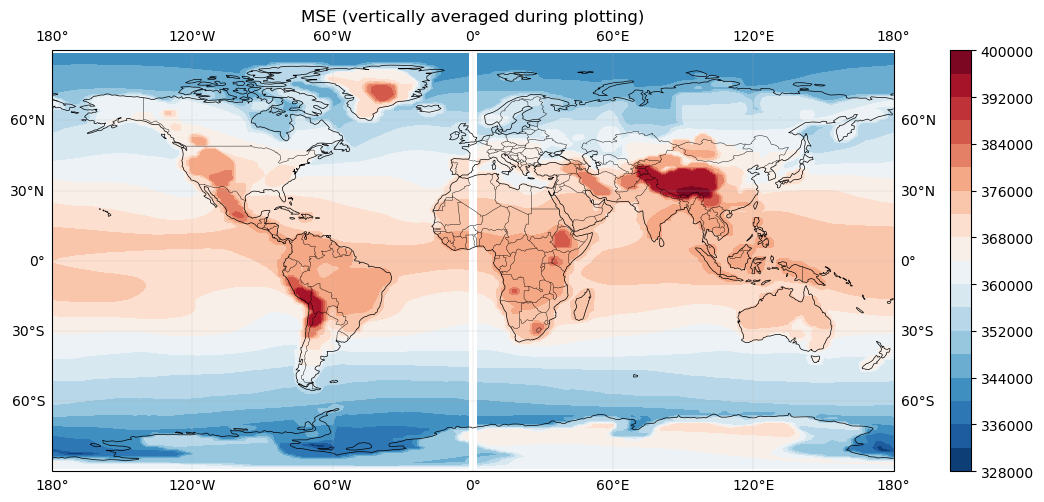

In [11]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
# v = ds['v_mean'].mean(dim="time") 
v = ds['h_on_v'].mean(dim=["time","plev"])
# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(ds.lon, ds.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("MSE (vertically averaged during plotting)")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



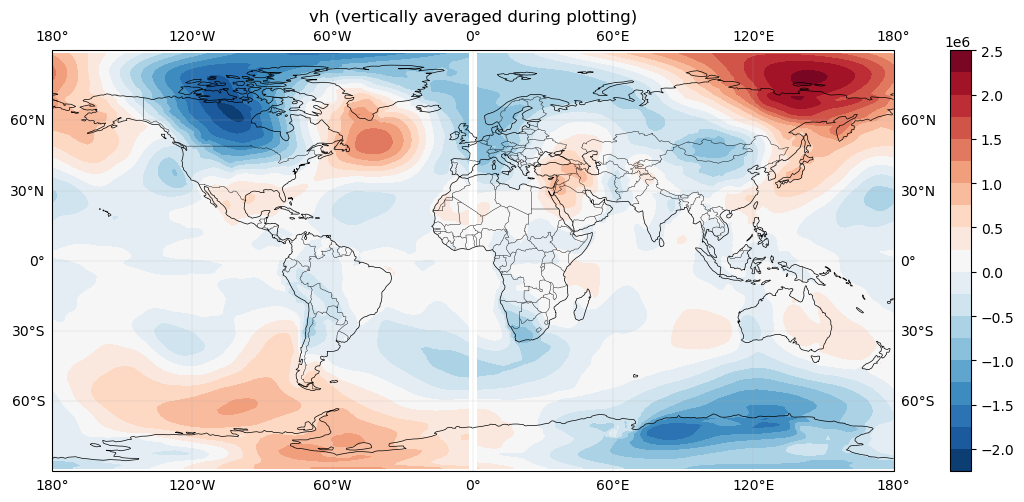

In [12]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
# v = ds['v_mean'].mean(dim="time") 
v = ds['vh'].mean(dim=["time","plev"])
# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(ds.lon, ds.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("vh (vertically averaged during plotting)")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



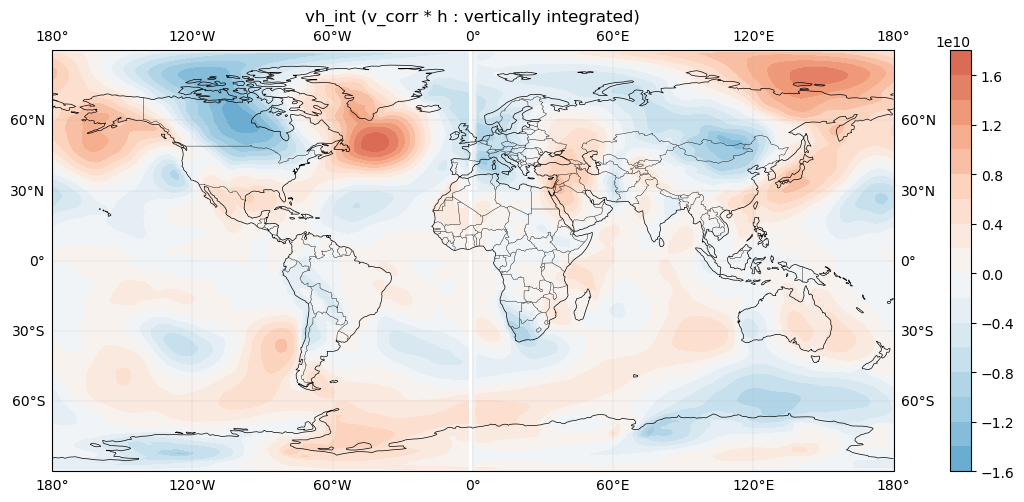

In [13]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
v = ds['vh_int'].mean(dim="time").sel(lat=slice(-90,90))
# v = ds['vh'].mean(dim=["time","plev"])
# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Set colorbar limits: -3e9 to 3e9
vmin = -3e10
vmax = 3e10

# im = ax.contourf(v.lon, v.lat, v,
#                  levels=20, cmap='RdBu_r', 
#                  vmin=vmin, vmax=vmax,
#                  transform=ccrs.PlateCarree())

im = ax.contourf(v.lon, v.lat, v, vmin=vmin, vmax=vmax,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())

plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("vh_int (v_corr * h : vertically integrated)")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()

Data min: -15475627994.09079
Data max: 17322309505.383167
Data mean: 15522905.704759559


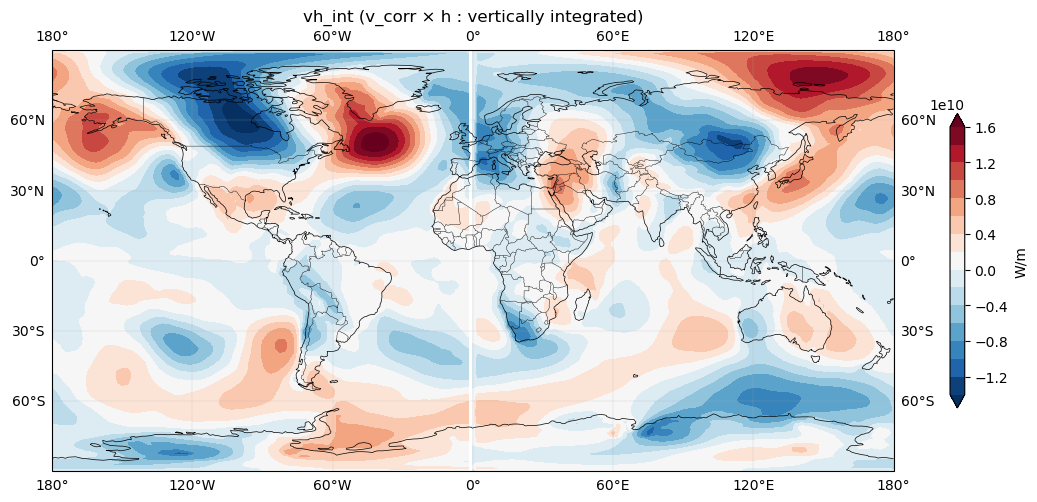

In [14]:
# First, check the actual data range
v = ds['vh_int'].mean(dim="time").sel(lat=slice(-90, 90))
print("Data min:", v.min().values)
print("Data max:", v.max().values)
print("Data mean:", v.mean().values)

# --- Plot ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Option 1: Use extend parameter to handle out-of-range values
vmin = -3e10
vmax = 3e10

im = ax.contourf(v.lon, v.lat, v, 
                 levels=20, cmap='RdBu_r', 
                 extend='both',  # Add this!
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label('W/m')
ax.set_title("vh_int (v_corr × h : vertically integrated)")
plt.tight_layout()
plt.show()

Data min: -15541575603.258326
Data max: 91840283200.12544
Data mean: 22940743454.143368


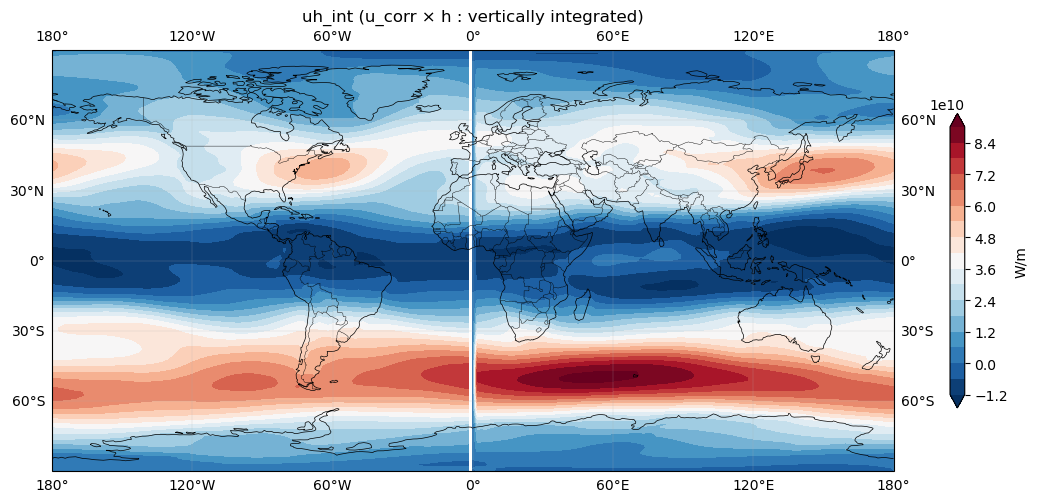

In [15]:
# First, check the actual data range
v = ds['uh_int'].mean(dim="time").sel(lat=slice(-90, 90))
print("Data min:", v.min().values)
print("Data max:", v.max().values)
print("Data mean:", v.mean().values)

# --- Plot ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Option 1: Use extend parameter to handle out-of-range values
vmin = -3e10
vmax = 3e10

im = ax.contourf(v.lon, v.lat, v, 
                 levels=20, cmap='RdBu_r', 
                 extend='both',  # Add this!
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label('W/m')
ax.set_title("uh_int (u_corr × h : vertically integrated)")
plt.tight_layout()
plt.show()

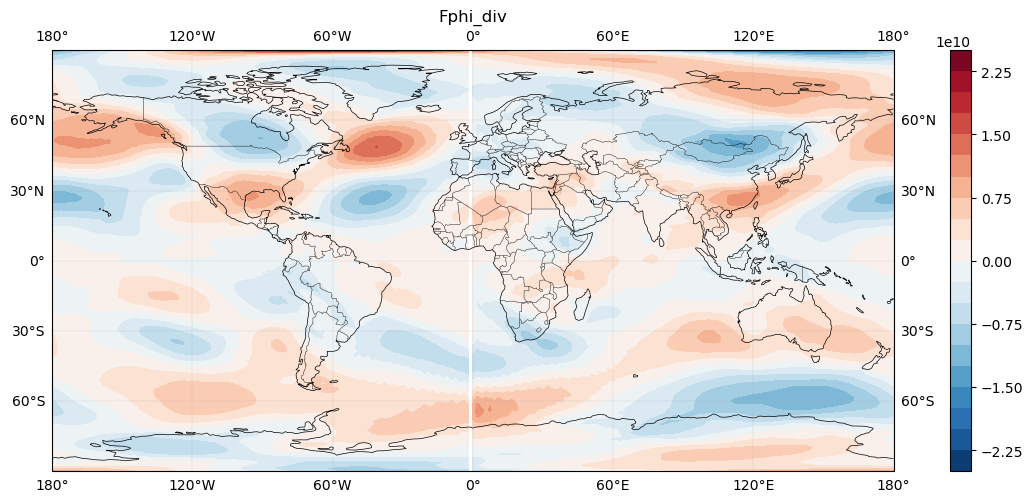

In [16]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
v = ds['Fphi_div'].mean(dim="time").sel(lat=slice(-90,90))
# v = ds['vh'].mean(dim=["time","plev"])
# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.lon, v.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("Fphi_div")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()

In [17]:
from windspharm.xarray import VectorWind

def windspharm_time_loop(uh_int, vh_int):
    """
    Compute divergent component for each time step
    """
    Flambda_div_list = []
    Fphi_div_list = []
    
    for t in range(len(uh_int.time)):
        # Extract single time step
        u_t = uh_int.isel(time=t)
        v_t = vh_int.isel(time=t)
        
        # VectorWind requires (lat, lon) with no NaNs
        u_filled = u_t.fillna(0.0)
        v_filled = v_t.fillna(0.0)
        
        # Compute divergent component
        vw = VectorWind(u_filled, v_filled)
        u_div, v_div = vw.irrotationalcomponent()  # Changed here!
        
        Flambda_div_list.append(u_div)
        Fphi_div_list.append(v_div)
    
    # Concatenate back along time dimension
    Flambda_div = xr.concat(Flambda_div_list, dim='time')
    Fphi_div = xr.concat(Fphi_div_list, dim='time')
    
    # Assign time coordinates
    Flambda_div = Flambda_div.assign_coords(time=uh_int.time)
    Fphi_div = Fphi_div.assign_coords(time=vh_int.time)
    
    return Flambda_div, Fphi_div

# # Use it
# uh_int = ds_e['tefle']  # Already integrated
# vh_int = ds_n['tefln']  # Already integrated

# Flambda_div, Fphi_div = windspharm_time_loop(uh_int, vh_int)

In [18]:
ds['uh_int']

<xarray.DataArray 'uh_int' (time: 720, lat: 145, lon: 192)> Size: 160MB
array([[[ 0.000000e+00,  0.000000e+00, ...,  0.000000e+00,  0.000000e+00],
        [ 0.000000e+00, -8.221898e+09, ..., -8.022608e+09, -8.096930e+09],
        ...,
        [ 0.000000e+00, -1.108308e+10, ..., -9.517814e+09, -1.004609e+10],
        [ 0.000000e+00,  0.000000e+00, ...,  0.000000e+00,  0.000000e+00]],

       [[ 0.000000e+00,  0.000000e+00, ...,  0.000000e+00,  0.000000e+00],
        [ 0.000000e+00, -2.365059e+08, ...,  4.794195e+07, -4.565646e+07],
        ...,
        [ 0.000000e+00, -3.209976e+10, ..., -3.005720e+10, -3.075448e+10],
        [ 0.000000e+00,  0.000000e+00, ...,  0.000000e+00,  0.000000e+00]],

       ...,

       [[ 0.000000e+00,  0.000000e+00, ...,  0.000000e+00,  0.000000e+00],
        [ 0.000000e+00, -1.813426e+10, ..., -1.957593e+10, -1.912076e+10],
        ...,
        [ 0.000000e+00, -4.117130e+09, ..., -1.446991e+09, -2.350797e+09],
        [ 0.000000e+00,  0.000000e+00, ...,  0.000000e+00,  0.000000e+00]],

       [[ 0.000000e+00,  0.000000e+00, ...,  0.000000e+00,  0.000000e+00],
        [ 0.000000e+00, -1.931382e+10, ..., -2.052403e+10, -2.014852e+10],
        ...,
        [ 0.000000e+00,  6.593233e+09, ...,  8.642258e+09,  7.966181e+09],
        [ 0.000000e+00,  0.000000e+00, ...,  0.000000e+00,  0.000000e+00]]],
      shape=(720, 145, 192))
Coordinates:
  * lat      (lat) float64 1kB -90.0 -88.75 -87.5 -86.25 ... 87.5 88.75 90.0
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * time     (time) object 6kB 2001-01-01 12:00:00 ... 2002-12-30 12:00:00
Attributes:
    long_name:  uh vertically integrated

In [19]:
uh=ds['uh_int']
vh=ds['vh_int']

In [20]:
# Reorder u and v to have descending latitude BEFORE VectorWind
if uh.lat.values[0] < uh.lat.values[-1]:
    uh = uh.sortby('lat', ascending=False)
    vh = vh.sortby('lat', ascending=False)

# # Now VectorWind will work correctly
# vw = VectorWind(uh.fillna(0.0), vh.fillna(0.0))
# u_div, v_div = vw.divergentcomponent()

In [31]:
print(uh)

<xarray.DataArray 'uh_int' (time: 720, lat: 145, lon: 192)> Size: 160MB
array([[[ 0.000000e+00,  0.000000e+00, ...,  0.000000e+00,  0.000000e+00],
        [ 0.000000e+00, -1.108308e+10, ..., -9.517814e+09, -1.004609e+10],
        ...,
        [ 0.000000e+00, -8.221898e+09, ..., -8.022608e+09, -8.096930e+09],
        [ 0.000000e+00,  0.000000e+00, ...,  0.000000e+00,  0.000000e+00]],

       [[ 0.000000e+00,  0.000000e+00, ...,  0.000000e+00,  0.000000e+00],
        [ 0.000000e+00, -3.209976e+10, ..., -3.005720e+10, -3.075448e+10],
        ...,
        [ 0.000000e+00, -2.365059e+08, ...,  4.794195e+07, -4.565646e+07],
        [ 0.000000e+00,  0.000000e+00, ...,  0.000000e+00,  0.000000e+00]],

       ...,

       [[ 0.000000e+00,  0.000000e+00, ...,  0.000000e+00,  0.000000e+00],
        [ 0.000000e+00, -4.117130e+09, ..., -1.446991e+09, -2.350797e+09],
        ...,
        [ 0.000000e+00, -1.813426e+10, ..., -1.957593e+10, -1.912076e+10],
        [ 0.000000e+00,  0.000000e+00, ...,  0.

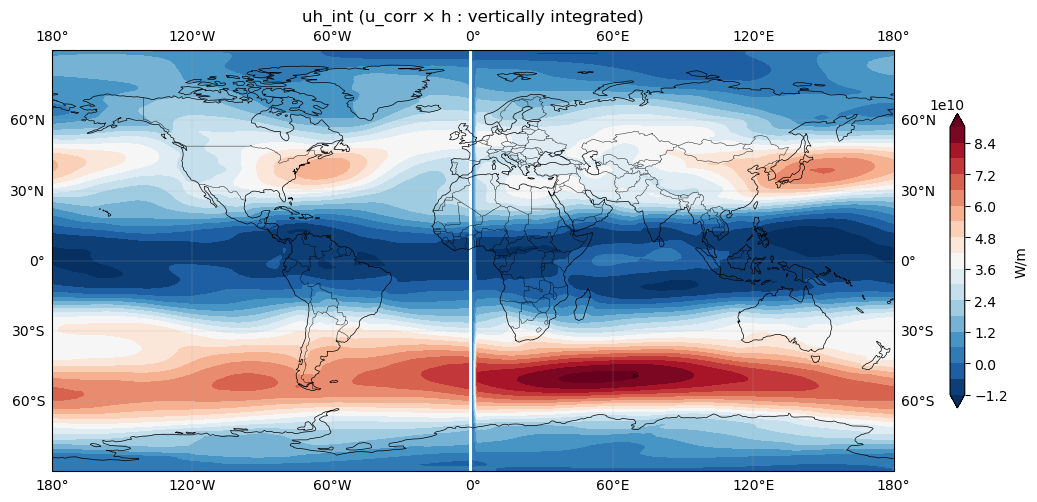

In [35]:
# First, check the actual data range
v = uh.mean(dim="time").sel(lat=slice(90, -90))
# print("Data min:", v.min().values)
# print("Data max:", v.max().values)
# print("Data mean:", v.mean().values)

# --- Plot ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Option 1: Use extend parameter to handle out-of-range values
vmin = -3e10
vmax = 3e10

im = ax.contourf(v.lon, v.lat, v, 
                 levels=20, cmap='RdBu_r', 
                 extend='both',  # Add this!
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label('W/m')
ax.set_title("uh_int (u_corr × h : vertically integrated)")
plt.tight_layout()
plt.show()

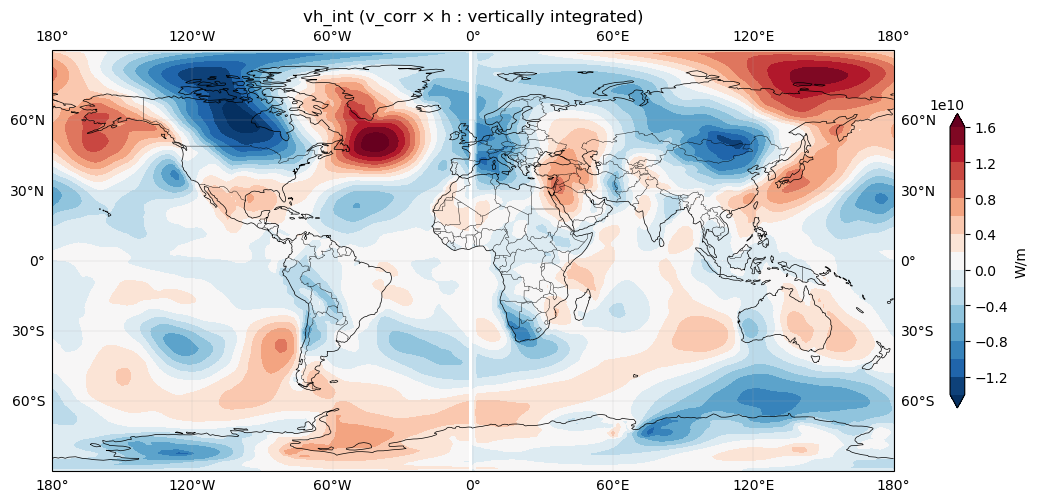

In [35]:
# First, check the actual data range
v = vh.mean(dim="time").sel(lat=slice(90, -90))
# print("Data min:", v.min().values)
# print("Data max:", v.max().values)
# print("Data mean:", v.mean().values)

# --- Plot ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Option 1: Use extend parameter to handle out-of-range values
vmin = -3e10
vmax = 3e10

im = ax.contourf(v.lon, v.lat, v, 
                 levels=20, cmap='RdBu_r', 
                 extend='both',  # Add this!
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label('W/m')
ax.set_title("vh_int (v_corr × h : vertically integrated)")
plt.tight_layout()
plt.show()

In [32]:
Flambda_div, Fphi_div = windspharm_time_loop(uh, vh)

In [33]:
Fphi_div_mean = Fphi_div.mean(dim='time')

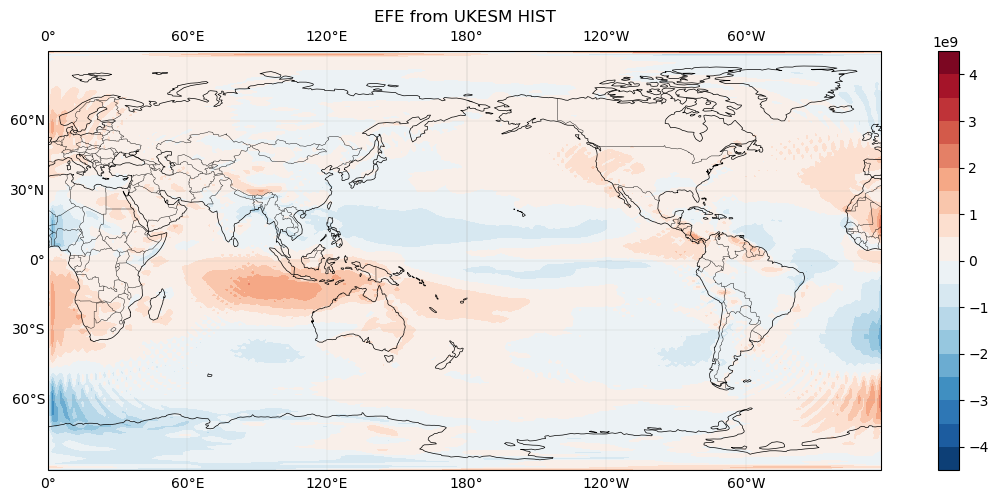

In [34]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
v = Fphi_div_mean

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.lon, v.lat, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title(f'EFE from UKESM HIST')
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()

